# 04 — Optimization and gradient descent

**Mathematical Foundations of Control and Machine Learning — Winter 2026**

Training a model means solving $\min_{x \in \mathbb{R}^d} f(x)$. Closed-form solutions are the exception, so we *descend*: stand at $x_k$, look at the slope, step downhill, repeat. Everything interesting is in the details.

1. **Gradient descent** — which direction, and how far?
2. **Why it converges** — $L$-smoothness, the descent lemma, and the proofs
3. **Momentum** — inertia, acceleration, and the optimal rate
4. **Non-convex problems** — why stochastic gradients help

In [1]:
%matplotlib inline
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from plotting import *            # the course palette, the house style, and the figure helpers

## 1. Gradient descent
Assume $f$ is differentiable and we want to minimize it
$$
\min_{x \in \mathbb{R}^d} f(x).
$$
Gradient descent is a first-order iterative optimization algorithm for finding a local minimum of a differentiable function.
Let us consider the first-order Taylor expansion
$$
f(x) = f(x_k) + \langle \nabla f(x_k),\, x - x_k \rangle + o(\|x - x_k\|)
$$
Then we want to find the minimum of this quadratic approximation. However, this problem has no unique solution, so we add a quadratic term that penalizes long steps:
$$
\begin{align*}
x_{k+1} &= \arg\min_{y \in \mathbb{R}^d} \Big\{ f(x_k) + \langle \nabla f(x_k),\, y - x_k \rangle + \tfrac{1}{2\eta}\|y - x_k\|^2 \Big\} \\ 
&= x_k - \eta \nabla f(x_k).
\end{align*}
$$
> We can see this gradient descent as $\dot x = -\nabla f(x)$ in continuous time, and the discrete-time version is obtained by Euler discretization with step size $\eta$.

The gradient picks the direction, the **step size** $\eta > 0$ picks how far.

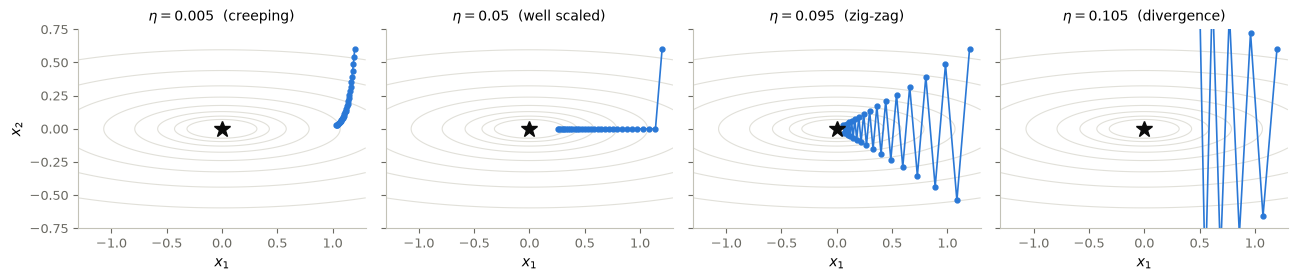

In [2]:
a1, a2 = 1.0, 20.0
f, grad = lambda x: 0.5 * (x[..., 0]**2 * a1 + x[..., 1]**2 * a2), lambda x: np.diag([a1, a2]) @ x

def gd(x0, eta, n=30):
    x, xs = np.array(x0, float), []
    for _ in range(n + 1):
        xs.append(x.copy())
        x = x - eta * grad(x)
    return np.array(xs)

g1, g2 = np.meshgrid(np.linspace(-1.3, 1.3, 300), np.linspace(-0.75, 0.75, 300))
Z = f(np.stack([g1, g2], -1))

fig, axes = panels(4, size=(3.25, 2.9), sharex=True, sharey=True)
for ax, (c, note) in zip(axes, [(0.1, "creeping"), (1, "well scaled"), (1.9, "zig-zag"), (2.1, "divergence")]):
    contour_path(ax, g1, g2, Z, path=gd([1.2, 0.6], c / a2, n=8 if c > 2 else 30),
                 optimum=(0, 0), color=BLUE, marker="-o", levels=np.geomspace(0.05, 12, 10),
                 xlabel="$x_1$", xlim=(-1.3, 1.3), ylim=(-0.75, 0.75),
                 title=rf"$\eta = {c / a2:g}$  ({note})")
axes[0].set_ylabel("$x_2$")
plt.show()

## 2. Convergence

**Assumption ($L$-smoothness).** $f$ is differentiable and $\nabla f$ is $L$-Lipschitz:

$$\|\nabla f(x) - \nabla f(y)\| \le L \|x - y\| \qquad \forall x, y,$$

equivalently $-L I \preceq \nabla^2 f(x) \preceq L I$ when $f$ is twice differentiable. Curvature is bounded, so the gradient measured at $x$ stays informative over a neighbourhood of radius $\sim 1/L$ — and nothing forces $f$ to be convex.

### Lemma (descent lemma)

$$f(y) \le f(x) + \langle \nabla f(x),\, y - x\rangle + \frac{L}{2}\|y - x\|^2 \qquad \forall x, y.$$

*Proof.* Write the increment along the segment $x + t(y-x)$, $t \in [0,1]$, with the fundamental theorem of calculus:

$$f(y) - f(x) - \langle \nabla f(x), y - x\rangle = \int_0^1 \big\langle \nabla f\big(x + t(y-x)\big) - \nabla f(x),\ y - x \big\rangle \, dt.$$

Bound the integrand with Cauchy–Schwarz and then with the Lipschitz assumption, $\|\nabla f(x + t(y-x)) - \nabla f(x)\| \le L t \|y-x\|$:

$$\le \int_0^1 L t \|y-x\|^2 \, dt = \frac{L}{2}\|y-x\|^2. \qquad \blacksquare$$

This is the whole mechanism in one line: **the quadratic model we minimized to derive gradient descent is a global upper bound on $f$ as soon as $1/\eta \ge L$.** Minimizing an upper bound that touches $f$ at $x_k$ cannot increase $f$.

### Theorem 1 (convergence to a stationary point)

Let $f$ be $L$-smooth and bounded below by $f^\star$, and let $0 < \eta \le 1/L$. Then gradient descent satisfies

$$f(x_{k+1}) \le f(x_k) - \frac{\eta}{2}\|\nabla f(x_k)\|^2 \qquad\text{and}\qquad \min_{0 \le k < K} \|\nabla f(x_k)\|^2 \le \frac{2\big(f(x_0) - f^\star\big)}{\eta K}.$$

*Proof.* Apply the lemma with $x = x_k$ and $y = x_{k+1} = x_k - \eta\nabla f(x_k)$:

$$f(x_{k+1}) \le f(x_k) - \eta\|\nabla f(x_k)\|^2 + \frac{L\eta^2}{2}\|\nabla f(x_k)\|^2 = f(x_k) - \eta\Big(1 - \frac{L\eta}{2}\Big)\|\nabla f(x_k)\|^2,$$

and $\eta L \le 1$ gives $1 - L\eta/2 \ge 1/2$, which is the first claim. Summing it for $k = 0, \dots, K-1$ telescopes:

$$\frac{\eta}{2}\sum_{k=0}^{K-1}\|\nabla f(x_k)\|^2 \le f(x_0) - f(x_K) \le f(x_0) - f^\star,$$

and the minimum of $K$ terms is at most their average. $\blacksquare$

### Theorem 2 (convex case)

If in addition $f$ is convex with a minimizer $x^\star$ and $0 < \eta \le 1/L$, then

$$f(x_K) - f^\star \le \frac{\|x_0 - x^\star\|^2}{2\eta K}.$$

*Proof.* Expand the distance to $x^\star$ and use convexity, $\langle \nabla f(x_k), x_k - x^\star\rangle \ge f(x_k) - f^\star$:

$$\|x_{k+1} - x^\star\|^2 = \|x_k - x^\star\|^2 - 2\eta \langle \nabla f(x_k), x_k - x^\star\rangle + \eta^2\|\nabla f(x_k)\|^2 \le \|x_k - x^\star\|^2 - 2\eta\big(f(x_k) - f^\star\big) + \eta^2 \|\nabla f(x_k)\|^2 .$$

Theorem 1 bounds the last term by the achieved decrease, $\eta^2\|\nabla f(x_k)\|^2 \le 2\eta\,(f(x_k) - f(x_{k+1}))$, so

$$\|x_{k+1} - x^\star\|^2 \le \|x_k - x^\star\|^2 - 2\eta\big(f(x_{k+1}) - f^\star\big).$$

Summing over $k < K$ telescopes the left side, and $f(x_k)$ is non-increasing, so the $K$ remaining terms are all at least $f(x_K) - f^\star$:

$$2\eta K \big(f(x_K) - f^\star\big) \le \sum_{k=0}^{K-1} 2\eta\big(f(x_{k+1}) - f^\star\big) \le \|x_0 - x^\star\|^2 - \|x_K - x^\star\|^2 \le \|x_0 - x^\star\|^2 . \qquad \blacksquare$$



| assumptions | measure | rate | iterations for $\varepsilon$ |
|---|---|---|---|
| $L$-smooth | $\min_k \lVert\nabla f(x_k)\rVert^2$ | $O(1/K)$ | $O(\varepsilon^{-2})$ |
| $L$-smooth $+$ convex | $f(x_K) - f^\star$ | $O(1/K)$ | $O(\varepsilon^{-1})$ |


## 3. Momentum

Gradient descent uses only the current gradient. In a narrow valley, it can zigzag across the steep sides while making slow progress along the valley. [Polyak’s heavy-ball method (1964)](https://www.mathnet.ru/eng/zvmmf7713) gives the iterate a **velocity** that carries part of each step into the next:

$$
v_{k+1}=\beta v_k-\eta\nabla f(x_k),\qquad
x_{k+1}=x_k+v_{k+1}.
$$

Here $\eta$ is the step size, and $\beta$ controls how much of the previous velocity is retained. When $\beta=0$, the method reduces to gradient descent.

The methods also have different continuous-time limits. Gradient descent approaches the first-order flow below when time advances by $\eta$ per step. Heavy ball approaches the second-order flow when time advances by $\sqrt{\eta}$ per step and $\beta=1-a\sqrt{\eta}$:

$$\begin{align*}&\dot x = -\nabla f(x), \qquad \tag{gradient descent} \\ &\ddot x + a\,\dot x + \nabla f(x) = 0. \qquad \tag{heavy ball}\end{align*}$$

Later on, other first-order methods appear such as [Nesterov’s accelerated method (1983)](https://www.mathnet.ru/eng/dan46009), [RMSProp (2012)](https://www.cs.toronto.edu/~hinton/coursera/lecture6/lec6.pdf), and [Adam (2014)](https://arxiv.org/abs/1412.6980).

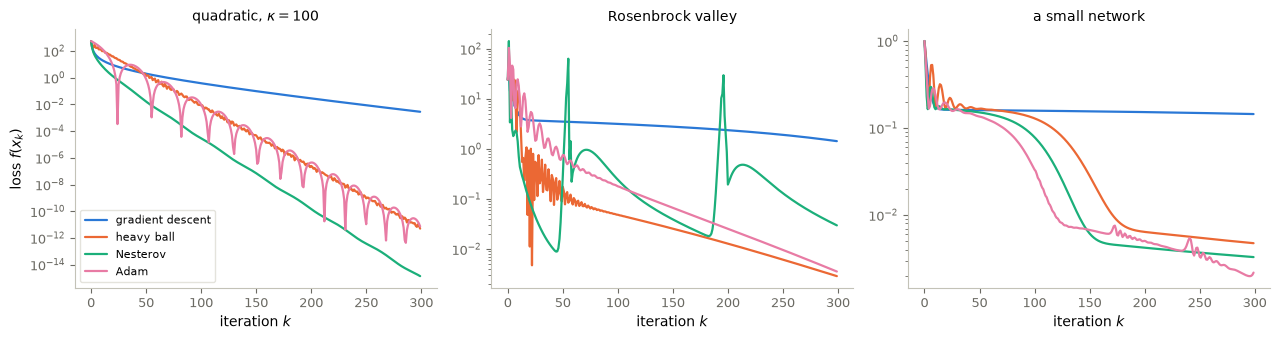

In [3]:
lam = torch.logspace(0, 2, 50)                                  # curvatures 1 ... 100, so kappa = 100
u = torch.linspace(-1, 1, 64)[:, None]; v = torch.sin(3 * u) + 0.3 * u

def quadratic():
    x = torch.ones(50, requires_grad=True)
    return [x], lambda: 0.5 * (lam * x**2).sum()

def rosenbrock():
    x = torch.tensor([-1.2, 1.0], requires_grad=True)
    return [x], lambda: (1 - x[0])**2 + 100 * (x[1] - x[0]**2)**2

def network():
    torch.manual_seed(0)
    net = nn.Sequential(nn.Linear(1, 32), nn.Tanh(), nn.Linear(32, 1))
    return list(net.parameters()), lambda: ((net(u) - v)**2).mean()

problems = {r"quadratic, $\kappa = 100$": (quadratic, 1 / 100, 0.05),     # (setup, step size, Adam step size)
            "Rosenbrock valley":          (rosenbrock, 2e-3, 0.5),
            "a small network":            (network, 5e-2, 0.03)}
methods = {"gradient descent": lambda p, eta, ad: torch.optim.SGD(p, eta),
           "heavy ball":       lambda p, eta, ad: torch.optim.SGD(p, eta, momentum=0.9),
           "Nesterov":         lambda p, eta, ad: torch.optim.SGD(p, eta, momentum=0.9, nesterov=True),
           "Adam":             lambda p, eta, ad: torch.optim.Adam(p, ad)}

def run(problem, method, n=300):
    setup, eta, ad = problems[problem]
    params, loss = setup()                                      # fresh start, identical for every method
    opt = methods[method](params, eta, ad)
    losses = []
    for _ in range(n):
        opt.zero_grad(); l = loss(); l.backward(); opt.step()
        losses.append(l.item())
    return losses

fig, axes = panels(3, size=(4.3, 3.5))
for ax, problem in zip(axes, problems):
    curves(ax, None, {method: (run(problem, method), col)
                      for method, col in zip(methods, [BLUE, ORANGE, AQUA, MAGENTA])},
           log="y", xlabel="iteration $k$", title=problem, legend=ax is axes[0])
axes[0].set_ylabel("loss $f(x_k)$")
plt.show()

## 4. Non-convex problems and the stochastic gradient

Machine learning objectives are not convex. Theorem 1 still holds — we reach a stationary point — but *which* one is decided by where we start: gradient descent is a descent method, and a descent method never leaves the basin it falls into. The remedy is to stop descending *exactly*. Perturb the gradient flow of Section 1 with white noise,

$$dX_t = -\nabla f(X_t)\,dt + \sigma\,dW_t,$$

with $W$ a $d$-dimensional Brownian motion and $\sigma > 0$ the noise level. The Euler–Maruyama discretization with step $\eta$ is the algorithm we actually run,

$$x_{k+1} = x_k - \eta\,\nabla f(x_k) + \sigma\sqrt{\eta}\,\xi_k, \qquad \xi_k \sim \mathcal{N}(0, I_d) \quad\text{i.i.d.},$$

the noise scaling as $\sqrt\eta$ because a Brownian increment over a time interval $\eta$ has standard deviation $\sqrt\eta$. This is **stochastic gradient descent**: the deterministic step, plus a kick.

### Theorem 3 (noise floor)

Let $f$ be $L$-smooth and bounded below by $f^\star$, and let $0 < \eta \le 1/L$. Then

$$\frac1K \sum_{k=0}^{K-1} \mathbb{E}\|\nabla f(x_k)\|^2 \;\le\; \underbrace{\frac{2\big(f(x_0) - f^\star\big)}{\eta K}}_{\text{the rate of Theorem 1}} \;+\; \underbrace{L \sigma^2 d}_{\text{noise floor}}.$$

*Proof.* The descent lemma with $x_{k+1} - x_k = -\eta\nabla f(x_k) + \sigma\sqrt\eta\,\xi_k$, in conditional expectation, using $\mathbb{E}\xi_k = 0$ and $\mathbb{E}\|\xi_k\|^2 = d$:

$$\mathbb{E}f(x_{k+1}) \le f(x_k) - \eta\|\nabla f(x_k)\|^2 + \frac{L}{2}\Big(\eta^2\|\nabla f(x_k)\|^2 + \sigma^2\eta\, d\Big) \le f(x_k) - \frac{\eta}{2}\|\nabla f(x_k)\|^2 + \frac{L\sigma^2 \eta\, d}{2},$$

using $\eta L \le 1$ in the last step. Take total expectations, sum over $k < K$, telescope, and divide by $\eta K / 2$. $\blacksquare$


In [4]:
f  = lambda z: 0.08 * (z**2).sum(-1) - np.cos(z[..., 0]) - np.cos(z[..., 1])
df = lambda z: 0.16 * z + np.sin(z)

def euler_maruyama(sigma, x0=(7.0, 6.3), eta=0.1, n=600, seed=0):
    rng, x, xs = np.random.default_rng(seed), np.array(x0, float), [np.array(x0, float)]
    for k in range(n):
        x = x - eta * df(x) + sigma(k) * np.sqrt(eta) * rng.standard_normal(2)
        xs.append(x.copy())
    return np.array(xs)

n = 300
sigma = lambda k: 1.1 * (1 - k / 600)                               # cooled linearly to zero
runs = [(r"gradient descent", euler_maruyama(lambda k: 0.0), BLUE),
        (r"noisy gradient", euler_maruyama(sigma), ORANGE)]

g = np.linspace(-9, 9, 300); G1, G2 = np.meshgrid(g, g); Z = f(np.stack([G1, G2], -1))
fig, (ax, axr) = panels(2, figsize=(9, 3.6), ratios=[1, 1.05], dpi=85)
ax.contourf(G1, G2, Z, levels=np.linspace(Z.min(), 13, 10),
            cmap=LinearSegmentedColormap.from_list("land", ["#ffffff", "#b3b2a8"]))
ax.contour(G1, G2, Z, levels=[0.7, 3.5], colors="white", linewidths=0.9)   # two basin boundaries
ax.plot(0, 0, "*", color=INK, ms=11)
label(ax, "$x_1$", "$x_2$", xlim=(-9, 9), ylim=(-9, 9), equal=True)
axr.axhline(f(np.zeros(2)), ls=":", color=INK, lw=1)
label(axr, "iteration $k$", "$f(x_k)$", xlim=(0, n), ylim=(-2.4, 9))

artists = []
for name, path, col in runs:
    line, = ax.plot([], [], color=col, lw=1.2)
    dot, = ax.plot([], [], "o", color=col, ms=6, label=name)
    curve, = axr.plot([], [], color=col, lw=1.4)
    artists.append((path, line, dot, curve))
ax.legend(loc="upper left")

def update(i):
    k = 5 * i
    for path, line, dot, curve in artists:
        line.set_data(*path[:k + 1].T)
        dot.set_data([path[k, 0]], [path[k, 1]])
        curve.set_data(np.arange(k + 1), f(path[:k + 1]))

animate(fig, update, n // 5 + 1, interval=200)